# BULC-D Early Detection — North Cascades National Park

A walkthrough of **BULC-D**, a Bayesian method for detecting landscape change from satellite imagery, with North Cascades National Park (2026 season) as the example. It is the same workflow, settings and structure as the Apostle Islands notebook (`early_detection_demo.ipynb`), applied to a much larger mountain landscape.

1. **What is BULC-D?** How it decides whether a place has changed.
2. **Setup and parameters.** The settings that matter, in plain terms.
3. **North Cascades example.** The outputs: change map, area totals, confidence, timing, imagery.
4. **Parameter effects.** The same place under different settings, side by side.
5. **Try your own area.** Draw an area, or use an Earth Engine asset.

*Prototype. The whole-park result is precomputed, so running the notebook takes about two minutes. Results have not been field-checked.*

In [1]:
import dataclasses
import datetime
import json
from pathlib import Path
from pprint import pprint

import ee
ee.Initialize(project="bulcd-python-rebuild")

from IPython.display import Markdown, display

from bulcd_early_detection import compare, drawing, outputs, render, report
from bulcd_early_detection.config import MonitoringControls, build_config, config_summary

OUT = Path("output")

## 1. What is BULC-D?

BULC-D (Bayesian Updating of Land Cover — Disturbance) asks one question for every 30 m pixel: *compared with how this place normally looks at this time of year, has it changed?* It answers by weighing many satellite observations, not by comparing two images.

1. **Learn "normal" (the baseline, or expectation, period).** For each pixel, BULC-D fits a smooth seasonal curve to several years of a vegetation index (NBR, which responds to green vegetation, moisture and burning). That gives an expected value for any day of the year, and how much the pixel normally varies.
2. **Compare each new observation (the monitoring period).** Every clear satellite image in the monitoring season is compared with the expected value. The difference, scaled by the pixel's normal variability, is a **z-score**: near 0 is normal, large negative values mean "much less vegetation than usual", large positive values mean "more".
3. **Turn each observation into evidence.** The z-score falls into one of 10 bins, and a fixed table (the **transition matrix**) says how strongly that bin points to *decrease*, *unchanged* or *increase*. A slightly low value is weak evidence; an extremely low one is strong evidence for decrease.
4. **Update the odds (Bayesian updating).** Each pixel starts at even odds for the three outcomes. Each observation updates the three probabilities, which carry forward to the next observation. One odd observation (a cloud edge, a shadow) can't flip the answer; a consistent run of evidence does.
5. **Decide.** At the end of the season, a pixel is mapped as **decrease** or **increase** if that outcome's probability exceeds the **decision threshold** (0.5 here). Otherwise it's **unchanged**.

| Outcome | Meaning | Examples |
|---|---|---|
| **Decrease / disturbance** | Vegetation signal consistently below its normal range | harvest, blowdown, fire, insects or disease, flooding, clearing |
| **Unchanged** | Within its normal range | |
| **Increase / growth** | Consistently above its normal range | regrowth, recovery |

BULC-D detects *spectral* change. It does not say *what caused* it; that takes local knowledge or a site visit.

The figure below shows the process for one real pixel at a 2026 fire in eastern Washington (not in this park). Before the fire, observations are near normal and *unchanged* stays most likely. After the fire, every observation is extreme, and the probability of *decrease* builds step by step until it crosses the threshold about four weeks later.

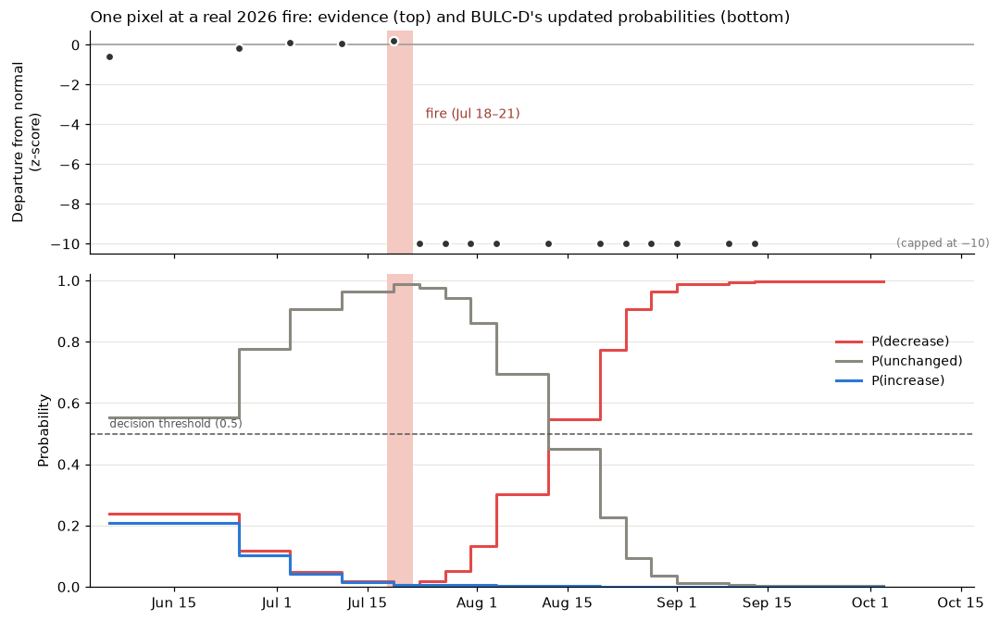

In [2]:
report.pixel_journey(Path("../experiments/output/fire_2026_production_matrix.csv"),
                     datetime.date(2026, 7, 18), datetime.date(2026, 7, 21), save_to=OUT / "pixel_journey.png");

## 2. BULC-D setup and parameters

The parameters that most affect the result, in plain terms. The first group are the everyday settings below; the rest are in the advanced configuration.

| Parameter | What it controls | This run |
|---|---|---|
| **Monitoring period** | The season checked for change | Jun 1 – Sep 30, 2026 |
| **Baseline period** | The years used to learn "normal", same season each year | 2018–2025 |
| **Decision threshold** | How sure BULC-D must be before a change is mapped | 0.5 |
| **Sensitivity** (`z_score_numerator_factor`) | Scales every departure from normal before it's scored. Higher flags smaller departures | 1.0 |
| *Advanced:* transition matrix | How strongly each level of departure counts as evidence | legacy app's default |
| *Advanced:* dampening (`dampening_factor`) | How much each single observation may move the probabilities (1 = full weight) | 0.5 |
| *Advanced:* posterior leveler (`posterior_leveler`) | After each update, pulls the probabilities slightly back toward even, so they don't lock in and a pixel can change its mind (1 = off) | 1.0 (off) |
| *Advanced:* sensors | Satellites used in each period | baseline Landsat 8; monitoring Landsat 8, Landsat 9, Sentinel-2 |
| *Advanced:* masks | Areas left out | water; non-forest land |

These are the same default settings as the Apostle Islands notebook; nothing was adjusted for North Cascades. Section 4 shows what several of them do to the map.

In [3]:
# Everyday settings, used by every section below.
controls = MonitoringControls(
    monitoring_year=2026,       # the season being checked for change
    season_start="06-01",       # MM-DD; the same window is used in every baseline year
    season_end="09-30",
    baseline_first_year=2018,   # "normal" is learned from these years (inclusive)
    baseline_last_year=2025,
    decision_threshold=0.5,     # map a change only where its probability exceeds this (0.5-0.99)
    sensitivity=1.0,            # z_score_numerator_factor; >1 flags smaller departures
)

### Advanced configuration

The settings above become a complete BULC-D configuration (`bulcd.config.schema.BULCDConfig`). Every BULC-D parameter stays available: edit it in `advanced()` and the change applies everywhere in this notebook. The full configuration is printed in section 3.

In [4]:
def advanced(config):
    # Edit any BULC-D config field here. Examples:
    # config.bulc_advanced_params.posterior_leveler = 0.9
    # config.evidence.target.sensors["S2"].enabled = False
    # config.study_area.mask_non_forest = False
    return config


def build(controls, **aoi):
    return advanced(build_config(controls, **aoi))

### Known differences from the legacy GEE app

This is a Python rebuild of BULC-D. It matches the legacy Google Earth Engine app in the transition matrix (traced to the app's own source; this matrix and configuration reproduced a legacy map with 97.9% agreement) and in how evidence is built. Known differences:

- **Levelers:** the legacy app uses a dampening (transition) leveler of 0.7, a posterior leveler of 0.9 and an initializing leveler of 0.7. This run uses 0.5, off, and off. How the rebuild should represent all three is still being reconciled.
- **Baseline sensors:** Landsat 8 only, because a Landsat + Sentinel-2 multi-year baseline exceeded an Earth Engine memory limit. Monitoring uses Landsat 8, Landsat 9 and Sentinel-2. Tests on small areas suggest this mismatch creates some spurious early-season detections; this is under investigation (`docs/findings.md`).
- **Masks:** water uses JRC Global Surface Water. The forest mask (Hansen tree cover in 2000) is a setting, not a BULC-D requirement; the legacy app has none. Non-forest land (rock, ice, alpine meadows) is not analyzed in this run — about a third of this park.
- **Park boundary:** North Cascades National Park from the World Database on Protected Areas (not an official NPS boundary file). Ross Lake and Lake Chelan National Recreation Areas are not included.

## 3. North Cascades example

The whole park (about 2,020 km² in two units), from a result computed in advance with the settings above. The notebook checks that the precomputed result matches the current settings.

In [5]:
PRECOMPUTED_FOLDER = "projects/bulcd-python-rebuild/assets/north_cascades"
PRECOMPUTED_RUN = "noca_2026_v1"

park = outputs.north_cascades()
park_config = build(controls, **park.aoi)
results, run_meta = outputs.load_precomputed(PRECOMPUTED_FOLDER, PRECOMPUTED_RUN)

expected = outputs.run_metadata(controls, park_config)
if not all(json.loads(m["controls_json"]) == json.loads(expected["controls_json"])
           and json.loads(m["config_json"]) == json.loads(expected["config_json"]) for m in run_meta):
    print("WARNING: the settings differ from the precomputed run. The maps in this section show the "
          "PRECOMPUTED settings; regenerate it with the maintenance cell at the end.")

size = outputs.aoi_size_report(park)
print(f"North Cascades National Park: {size['area_km2']:,.0f} km² inside the boundary")
display(Markdown("**Settings for this run**\n\n| Setting | Value |\n|---|---|\n"
                 + "\n".join(f"| {k} | {v} |" for k, v in config_summary(park_config))))

token = render.auth_token()
frame, bbox = report.frame_for(park.geometry)
season = report.season_label(controls)
park_out = OUT / f"north_cascades_{controls.monitoring_year}"

North Cascades National Park: 2,022 km² inside the boundary


**Settings for this run**

| Setting | Value |
|---|---|
| Baseline (expectation) period | L8; years [(2018, 2025)]; DOY [(152, 273)] |
| Monitoring (target) period | L8, L9, S2; years [(2026, 2026)]; DOY [(152, 273)] |
| Spectral index | NBR |
| Expectation model | constant, unimodal |
| Sensitivity (z-score numerator factor) | 1.0 |
| Transition matrix | production (legacy default) |
| dampening_factor | 0.5 |
| posterior_leveler | 1.0 |
| initializing_leveler | 0.0 |
| recency_factor | 1.0 |
| Water mask / non-forest mask | True / True |

In [6]:
# Full BULC-D configuration, for technical users.
pprint(dataclasses.asdict(park_config), width=110, compact=True)

{'bin_cuts': [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2],
 'bulc_advanced_params': {'custom_transition_matrix': [[0.83, 0.08, 0.08], [0.66, 0.24, 0.08],
                                                       [0.53, 0.37, 0.08], [0.14, 0.76, 0.08],
                                                       [0.08, 0.83, 0.08], [0.08, 0.83, 0.08],
                                                       [0.08, 0.76, 0.14], [0.08, 0.37, 0.53],
                                                       [0.08, 0.24, 0.66], [0.08, 0.08, 0.83]],
                          'dampening_factor': 0.5,
                          'initializing_leveler': 0.0,
                          'posterior_leveler': 1.0,
                          'raw': {},
                          'recency_factor': 1.0},
 'evidence': {'day_step_size': 4,
              'expectation': {'sensors': {'L8': {'cloud_cover_threshold': 70,
                                                 'enabled': True,
                                               

### Change this season

**The primary map.** Red: decrease/disturbance. Blue: increase/growth. Gray: unchanged. Lighter gray: land not analyzed (non-forest: rock, ice, alpine). Water is pale blue and not analyzed.

*Changes are drawn slightly enlarged on park-wide maps so small patches stay visible; area totals use the exact 30 m pixels. The close-up below shows true extents.*

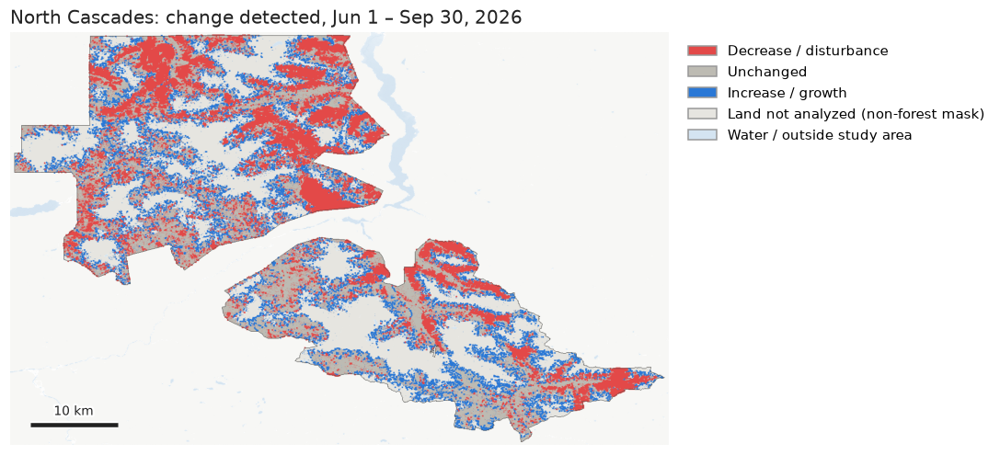

In [7]:
report.outcome_map(results, park, frame, bbox, f"North Cascades: change detected, {season}", token,
                   save_to=park_out / "outcome.png");

### Area by outcome
Land only; water is excluded.

In [8]:
table, park_areas = report.area_table(results, park.geometry)
display(Markdown(table))

| Outcome | Area (km²) | Share of analyzed land |
|---|---:|---:|
| Decrease / disturbance | 375.76 | 31.6% |
| Unchanged | 783.57 | 65.9% |
| Increase / growth | 29.97 | 2.5% |
| Land not analyzed (non-forest mask) | 832.86 | — |

### How confident is each mapped change?
The final probability of each mapped change; darker is more certain. Only change pixels are colored, since unchanged land sits near 1.0 almost everywhere.

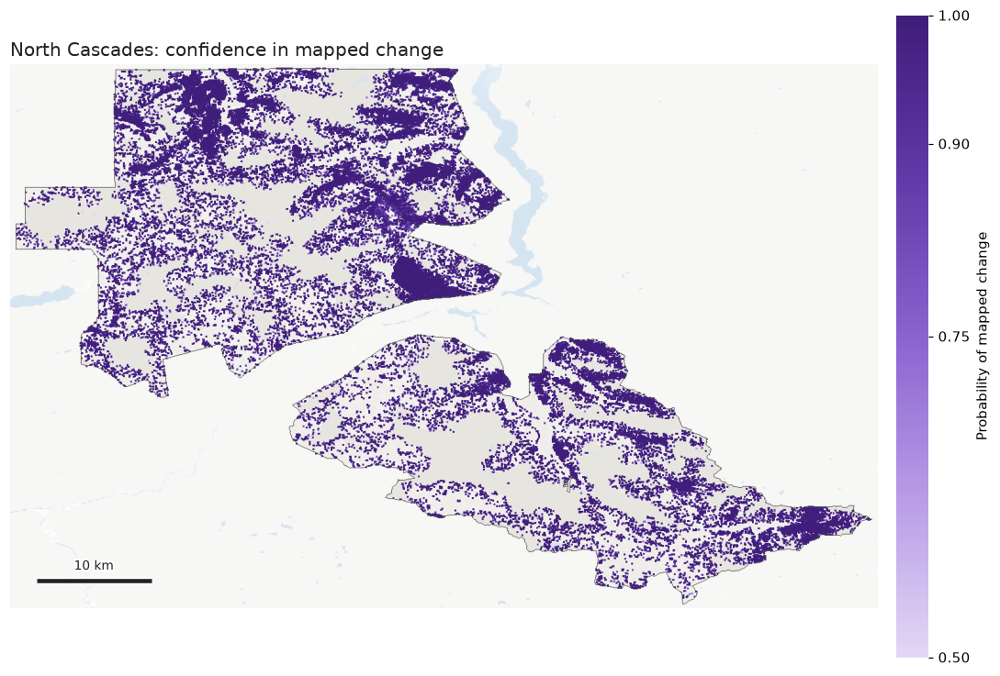

In [9]:
report.confidence_map(results, park, frame, bbox, "North Cascades: confidence in mapped change", token,
                      controls.decision_threshold, save_to=park_out / "confidence.png");

### When was each change first detected?
The first date a pixel's change probability passed the decision threshold (4-day resolution). A change that *happens during* the season is usually detected a few weeks later (section 1). A change detected in the **first days of the season** was most likely already different from normal when observations began.

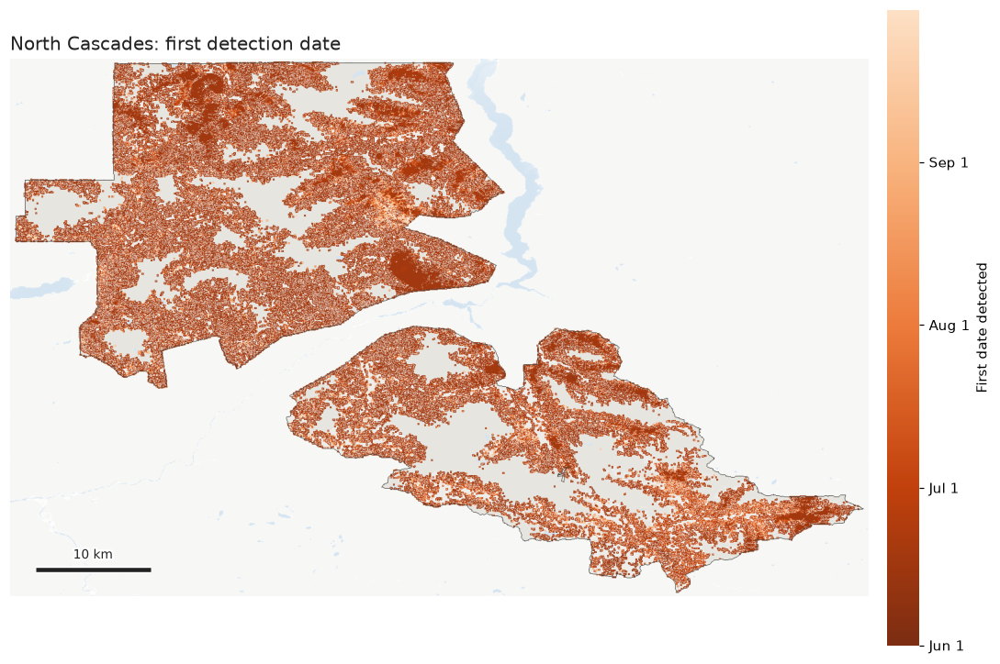

Mapped change: 405.73 km², of which 1% was first detected in the first two weeks of the season.


In [10]:
report.timing_map(results, park, frame, bbox, "North Cascades: first detection date", token, controls,
                  save_to=park_out / "first_detection.png")
timing = outputs.early_detection_share(results, park.geometry, controls.first_doy)
print(f"Mapped change: {timing['changed_km2']:.2f} km², of which {100 * timing['early_share']:.0f}% was first "
      "detected in the first two weeks of the season.")

### Satellite imagery: before and after
Sentinel-2 false color (shortwave infrared / near infrared / red), independent of BULC-D. Healthy forest is green, bare or damaged ground orange-brown to magenta, snow and ice cyan, water dark. Both images are **September 5–30** composites: the last baseline year, then this year. (The Apostle Islands notebook uses the whole later half of the season; here, late July through August 2026 is heavily hazed, so only September is used.)

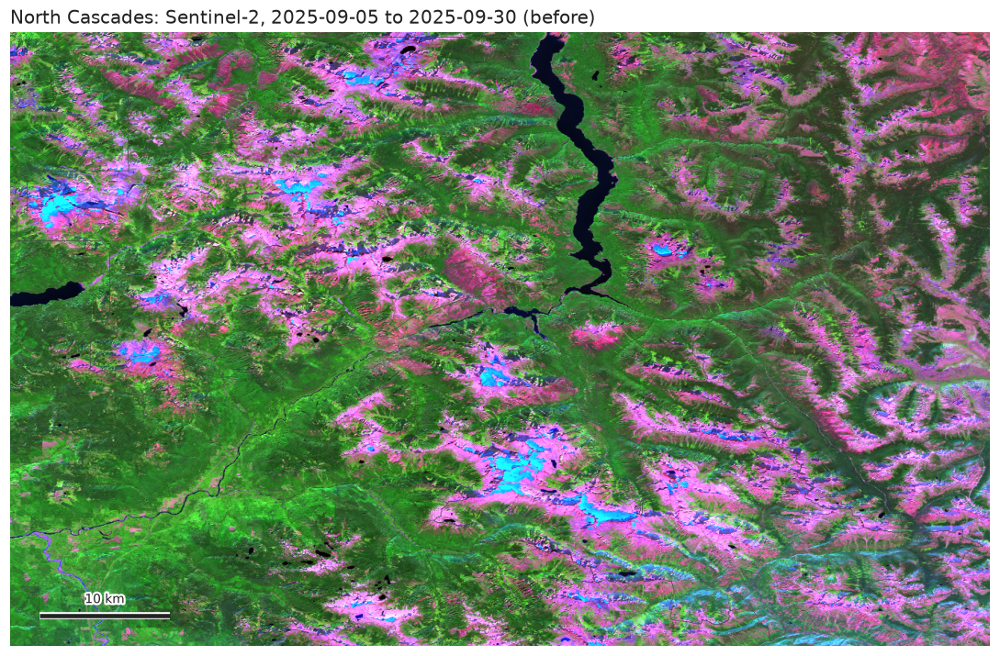

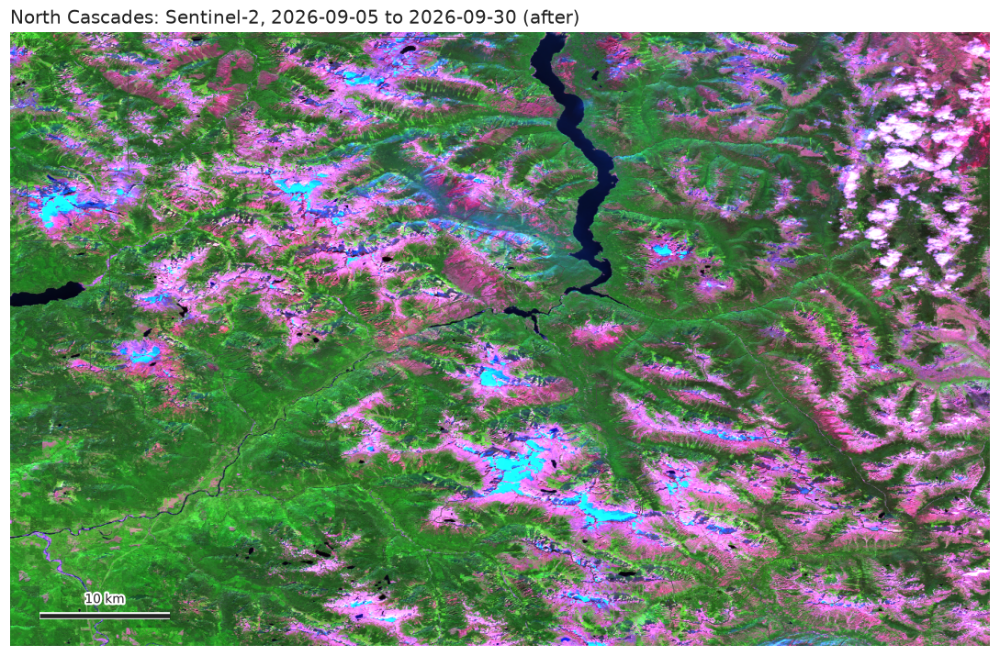

In [11]:
report.reference_pair(park, frame, bbox, "North Cascades", token, controls, park_out, window=("09-05", "09-30"));

### Close-up: the comparison area

At park scale a 30 m pixel is smaller than a screen pixel, so here is one 5 km box at true resolution (23 km², north unit, 48.83° N 121.19° W). It holds the park's largest patch of 2026 vegetation loss visible in independent Sentinel-2 imagery. Section 4 uses this same extent.

The 2026 seasonal imagery here is badly hazed from about July 20 onward, so the close-up uses **single clear dates** instead: the same time last year, the last clear date before the change this season, and a clear date after it. The change appears between July 15 and 20, 2026. Its cause has not been confirmed.

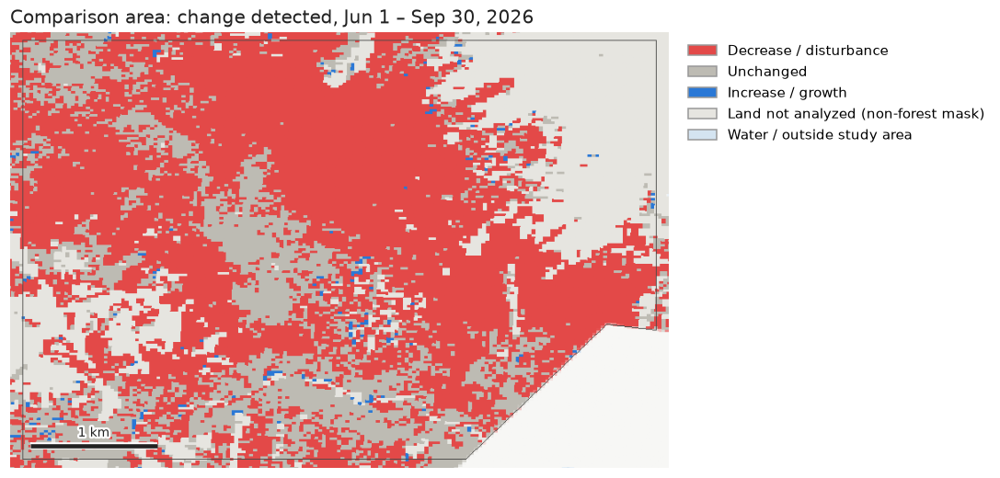

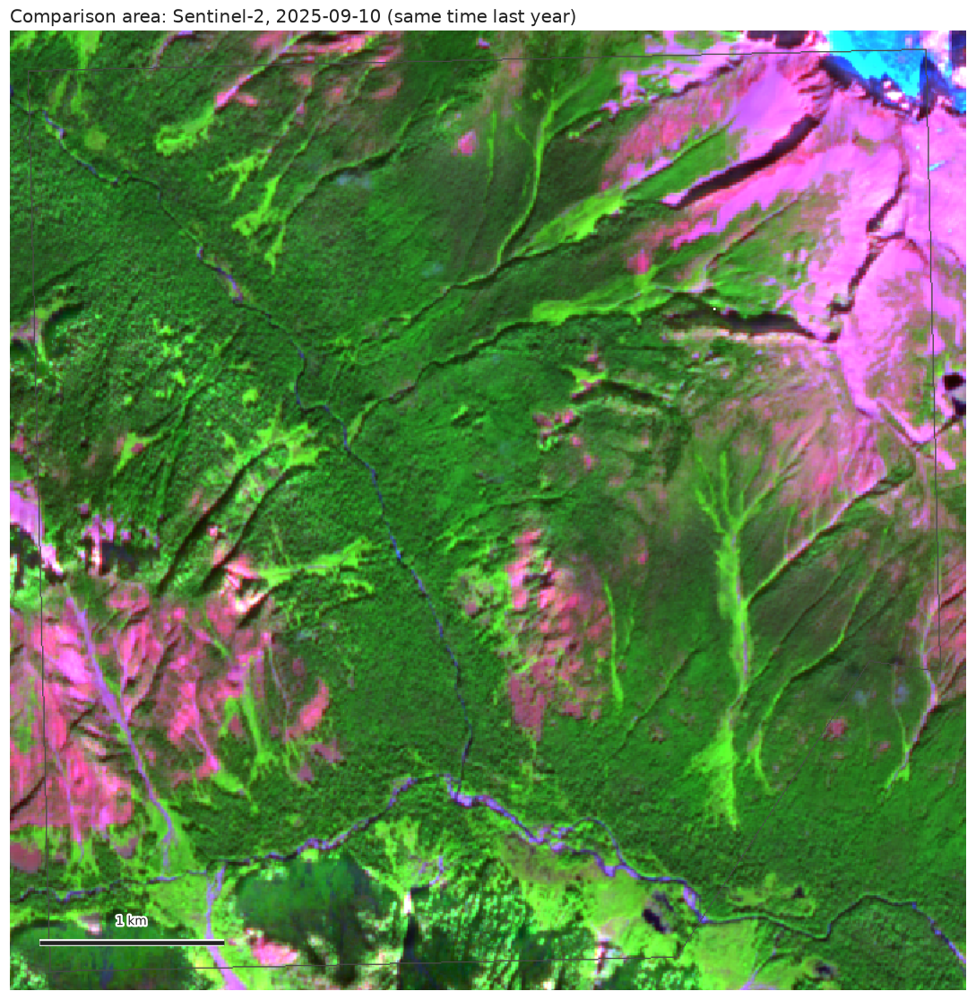

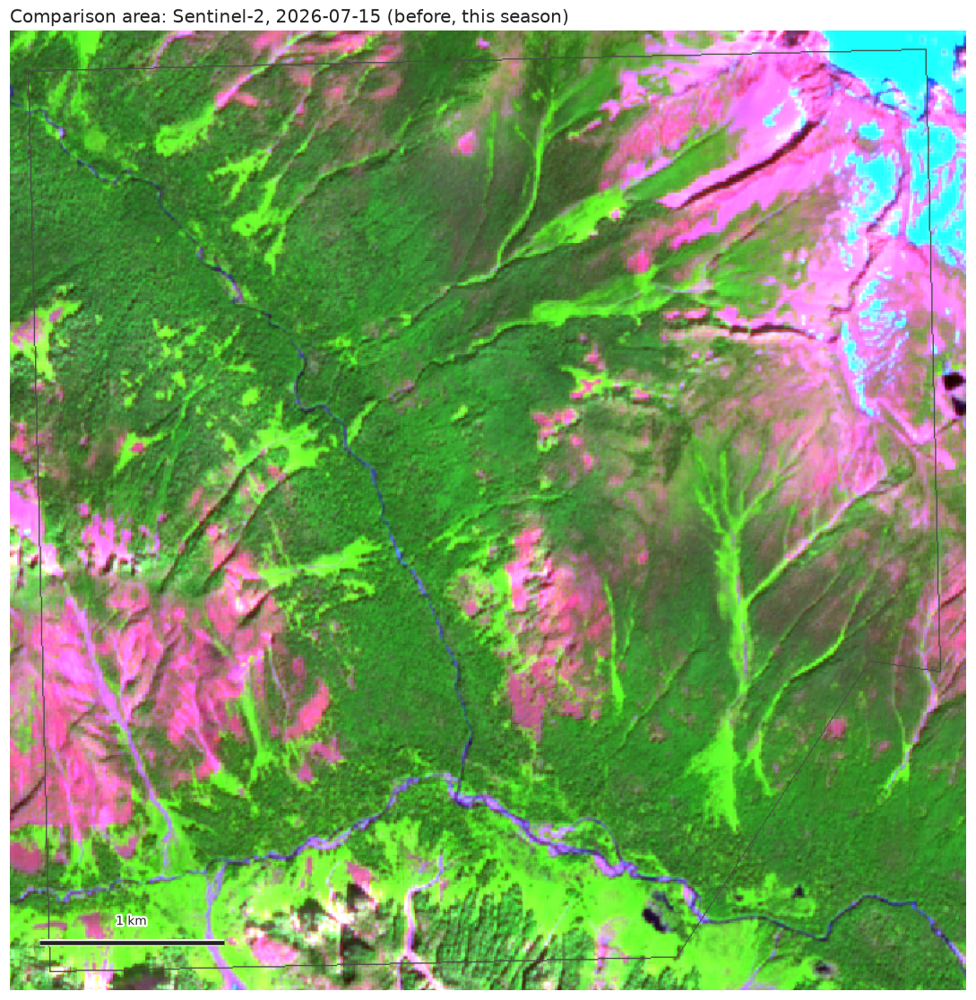

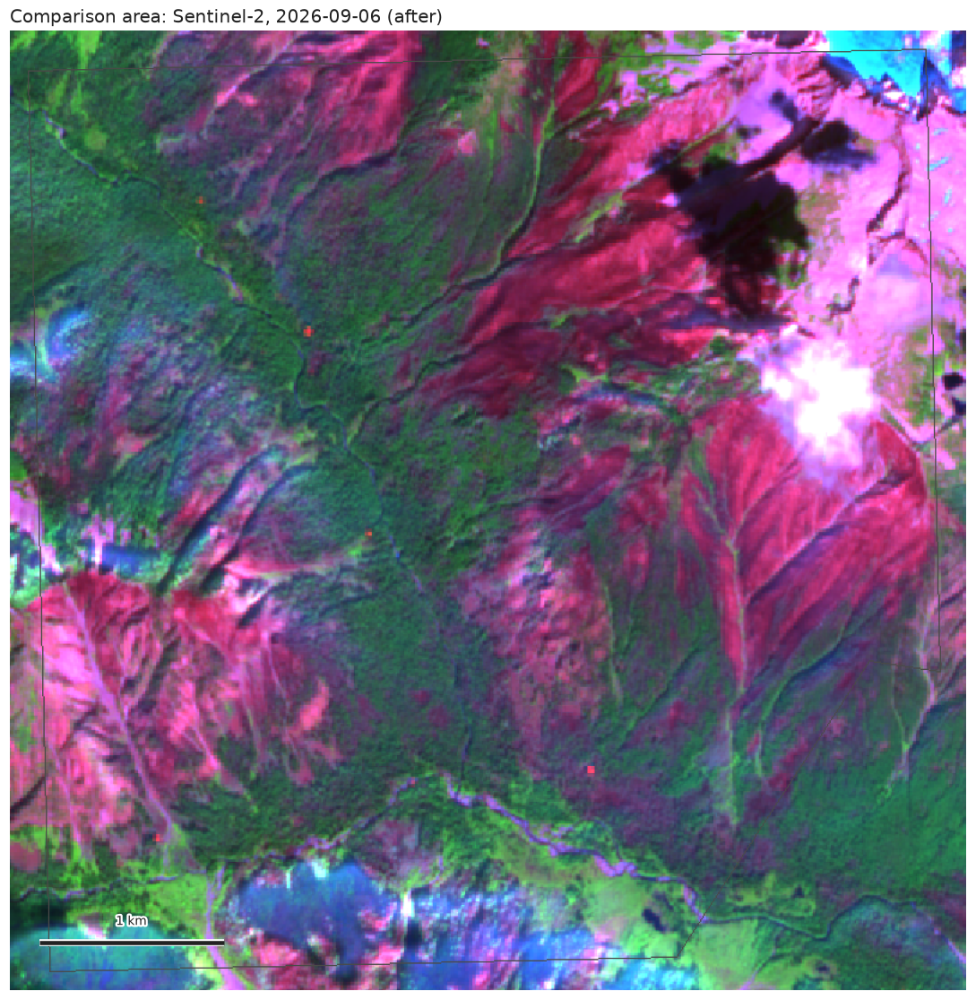

In [12]:
box = drawing.study_area("noca_comparison_box")
box_frame, box_bbox = report.frame_for(box.geometry, pad_m=100)
box_out = OUT / "noca_comparison_box"
report.outcome_map(results, box, box_frame, box_bbox, f"Comparison area: change detected, {season}", token,
                   save_to=box_out / "outcome.png", enlarge_changes=False, dimensions=800)
report.scene_series(box, box_frame, box_bbox, "Comparison area", token, [
    ("same time last year", "20250910T190821_20250910T190823_T10UFV"),
    ("before, this season", "20260715T185921_20260715T190728_T10UFV"),
    ("after", "20260906T190921_20260906T191705_T10UFV"),
], box_out);

### What this run shows (prepared 2026-09-29)

These notes describe the precomputed 2026 result with the default settings, which were **not** adjusted for this park.

- **Much more change is mapped than at Apostle Islands.** About 32% of analyzed forest is mapped as decrease (376 km² of 1,189 km²), and 2.5% as increase. At Apostle Islands it was 1.4% decrease. About 833 km² of the park (rock, ice, alpine) is not analyzed.
- **The change is widespread, heaviest in the north unit,** not confined to a few distinct patches.
- **Almost none of it (about 1%) was first detected in early June**, unlike Apostle Islands. Here it mostly appears later in the season.
- **The comparison area shows a clearly visible change** in clear single-date imagery, starting between July 15 and 20, 2026. Most of the rest of the mapped change has not been checked against imagery.
- **Why so much decrease is mapped here has not been investigated.** Possibilities include real 2026 change, haze or smoke in the monitoring imagery, and how well a baseline built for gentler terrain fits steep mountain forest. **None of it has been field-checked or matched to records.**

## 4. Parameter effects

What changes when BULC-D's settings change? Each map below is **the comparison area at exactly the same extent**, with **one** setting changed from section 2 and everything else held the same. These are the same six maps as in the Apostle Islands notebook. The goal is to show what each parameter does, not to pick the "best" settings.

| Map | What changed | What that parameter means |
|---|---|---|
| **Current settings** | Nothing (reference) | The settings in section 2. |
| **Decision threshold 0.9** | 0.5 → 0.9 | How sure BULC-D must be before mapping a change. Higher maps only the strongest evidence. |
| **Sensitivity 0.5** | 1.0 → 0.5 | Halves every departure from normal before it's scored, so only large departures count as strong evidence. |
| **Sensitivity 2.0** | 1.0 → 2.0 | Doubles every departure, so small departures count as strong evidence. |
| **Dampening 0.7** | 0.5 → 0.7 (the legacy app's value) | How much weight each single observation carries. Higher lets each observation move the probabilities further. |
| **Posterior leveler 0.9** | off → 0.9 (the legacy app's value) | After each observation, pulls the probabilities slightly back toward even, so evidence must keep accumulating. |

Each setting that changes BULC-D's inputs is a new Earth Engine run (5–10 s here). The threshold only re-reads existing probabilities, so it's free.

Current settings: running BULC-D ... 

6 s
Decision threshold 0.9: reusing an earlier run (differs only in threshold/masks)
Sensitivity 0.5: running BULC-D ... 

3 s
Sensitivity 2.0: running BULC-D ... 

13 s
Dampening 0.7: running BULC-D ... 

4 s
Posterior leveler 0.9: running BULC-D ... 

4 s


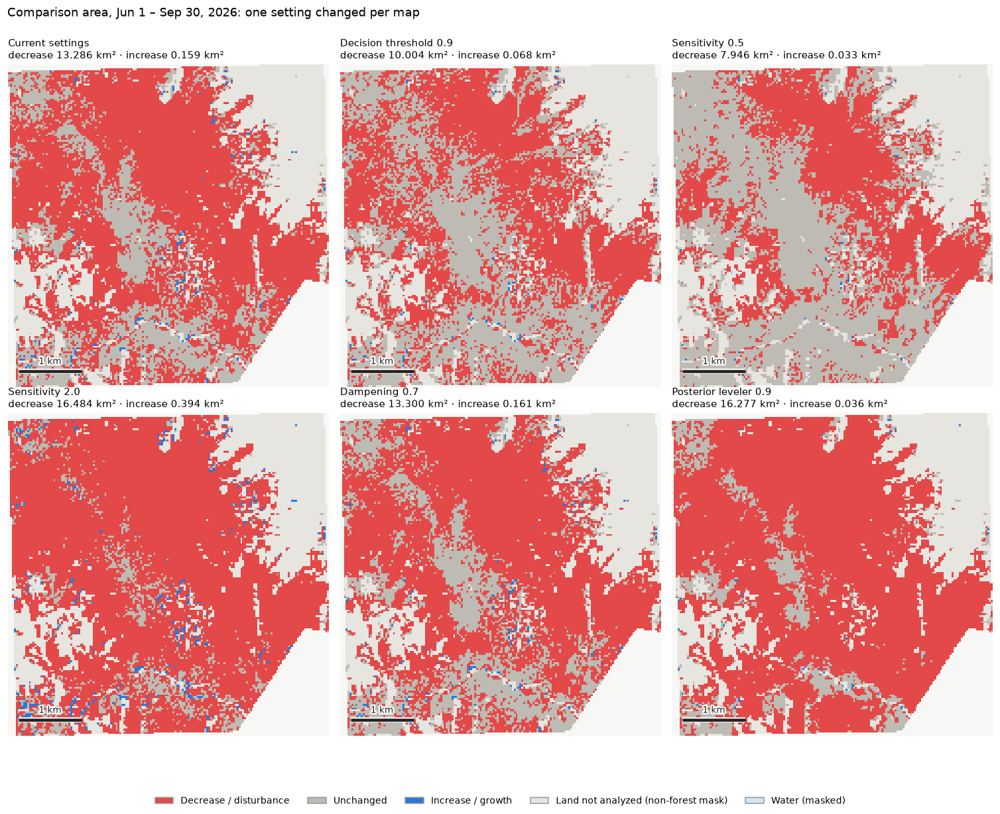

| Variant | Decrease / disturbance (km²) | Increase / growth (km²) | Unchanged (km²) | Land not analyzed (non-forest mask) (km²) | What it tests |
|---|---:|---:|---:|---:|---|
| Current settings | 13.286 | 0.159 | 5.297 | 4.963 | Reference: the section 2 settings. |
| Decision threshold 0.9 | 10.004 | 0.068 | 8.671 | 4.963 | Higher bar before a change is mapped. |
| Sensitivity 0.5 | 7.946 | 0.033 | 10.763 | 4.963 | Departures from normal halved. |
| Sensitivity 2.0 | 16.484 | 0.394 | 1.864 | 4.963 | Departures from normal doubled. |
| Dampening 0.7 | 13.300 | 0.161 | 5.281 | 4.963 | Each observation weighs more (legacy value). |
| Posterior leveler 0.9 | 16.277 | 0.036 | 2.429 | 4.963 | Probabilities pulled toward even after each update (legacy value). |

In [13]:
def set_advanced(field, value):
    def edit(config):
        setattr(config.bulc_advanced_params, field, value)
    return edit


V = compare.Variant
parameter_variants = [
    V("Current settings", "Reference: the section 2 settings."),
    V("Decision threshold 0.9", "Higher bar before a change is mapped.", controls={"decision_threshold": 0.9}),
    V("Sensitivity 0.5", "Departures from normal halved.", controls={"sensitivity": 0.5}),
    V("Sensitivity 2.0", "Departures from normal doubled.", controls={"sensitivity": 2.0}),
    V("Dampening 0.7", "Each observation weighs more (legacy value).", edit=set_advanced("dampening_factor", 0.7)),
    V("Posterior leveler 0.9", "Probabilities pulled toward even after each update (legacy value).",
      edit=set_advanced("posterior_leveler", 0.9)),
]

effects = compare.run_comparison(box, controls, build, parameter_variants)
compare.show_comparison(effects, f"Comparison area, {season}: one setting changed per map", save_to=box_out / "parameter_effects.png")
display(Markdown(compare.comparison_table(effects)))

**How to read it** (observed with the section 2 settings):

- **Sensitivity has a large effect,** as on Devils Island: halving it cuts the mapped decrease from about 13 km² to 8 km², mostly on the valley floor; doubling it spreads decrease over almost all analyzed forest.
- **The decision threshold matters more here** than on Devils Island (13 → 10 km²). The change began mid-season, so by the end of September many pixels are still building evidence (probability between 0.5 and 0.9).
- **The posterior leveler *increases* the mapped decrease here** (13 → 16 km²), the opposite of Devils Island. It keeps probabilities from locking in, so pixels that looked normal until mid-July can switch to decrease faster once the change starts. On Devils Island, the change was already present in June.
- **Dampening 0.7 barely changes anything,** as on Devils Island.
- **The large patches in the upper and eastern parts of the box persist under every setting.** They largely coincide with the magenta slopes in the "after" image above.

### Whole park: the decision threshold

The threshold only re-reads the final probabilities, so it can be applied to the whole-park precomputed result without re-running BULC-D.

In [14]:
rows = []
for t in (0.5, 0.9):
    _, a = report.area_table(outputs.reclassify(results, t), park.geometry)
    rows.append(f"| {t} | {a[outputs.OUTCOME_LABELS[outputs.DECREASE]]:.2f} | "
                f"{a[outputs.OUTCOME_LABELS[outputs.INCREASE]]:.2f} | {a[outputs.OUTCOME_LABELS[outputs.UNCHANGED]]:.2f} |")
display(Markdown("| Decision threshold | Decrease (km²) | Increase (km²) | Unchanged (km²) |\n|---:|---:|---:|---:|\n"
                 + "\n".join(rows)))

| Decision threshold | Decrease (km²) | Increase (km²) | Unchanged (km²) |
|---:|---:|---:|---:|
| 0.5 | 375.76 | 29.97 | 783.57 |
| 0.9 | 326.45 | 23.65 | 839.21 |

## 5. Try your own area

The same workflow can run on any area, **live** (a few minutes for a few km²). Two ways to define it:

- **Draw it:** set `TRY_OWN_AREA = True` and `AOI_MODE = "draw"`, and choose a new `DRAWN_AOI_NAME`. Run the next cell, draw a polygon or rectangle on the map, then run the save cell. The area is saved as `aois/<name>.geojson` and can be reloaded by name later, with no redrawing.
- **Use an Earth Engine asset:** set `AOI_MODE = "asset"` and `CUSTOM_AOI_ASSET` to a FeatureCollection asset ID.

Then run the remaining cells. The size is checked first: areas over 100 km² get a warning, and areas over 1,000 km² are blocked unless `ALLOW_LARGE_AOI = True`. Drawing needs JupyterLab 4, Notebook 7 or VS Code.

In [15]:
TRY_OWN_AREA = False
AOI_MODE = "draw"                        # "draw" or "asset"
DRAWN_AOI_NAME = "noca_comparison_box"   # saved as aois/<name>.geojson (this one is the section 4 area)
CUSTOM_AOI_ASSET = "projects/your-project/assets/your_feature_collection"
ALLOW_LARGE_AOI = False
COMPARE_OWN_AREA = False                 # also run section 4's variants on your area

if TRY_OWN_AREA and AOI_MODE == "draw":
    saved = drawing.aoi_path(DRAWN_AOI_NAME)
    detections = results.select("outcome")
    detections = detections.updateMask(detections.eq(outputs.DECREASE).Or(detections.eq(outputs.INCREASE)))
    overlay = drawing.ee_tile_layer(
        detections.visualize(min=0, max=2, palette=[render.OUTCOME_COLORS[0][1:], "ffffff", render.OUTCOME_COLORS[2][1:]]),
        "North Cascades 2026 detections")
    drawer = drawing.AOIDrawer(center=(48.68, -121.14), zoom=9, overlays=[overlay], existing=drawing.load_polygon(DRAWN_AOI_NAME) if saved.exists() else None)
    display(drawer.map)
    print(f"Saved area {DRAWN_AOI_NAME!r}: {'found (yellow)' if saved.exists() else 'not saved yet - draw one, then run the next cell'}")
elif not TRY_OWN_AREA:
    print("Skipped (set TRY_OWN_AREA = True).")

Skipped (set TRY_OWN_AREA = True).


In [16]:
# Run after drawing, to save the drawn shape as DRAWN_AOI_NAME.
if TRY_OWN_AREA and AOI_MODE == "draw":
    path = drawer.save(DRAWN_AOI_NAME)
    if path:
        print(f"Saved {path}")
    elif drawing.aoi_path(DRAWN_AOI_NAME).exists():
        print(f"Nothing new drawn - using the saved {DRAWN_AOI_NAME!r}.")
    else:
        print("Nothing drawn yet: draw on the map above, then run this cell again.")

In [17]:
if TRY_OWN_AREA:
    own = drawing.study_area(DRAWN_AOI_NAME) if AOI_MODE == "draw" else outputs.from_asset(CUSTOM_AOI_ASSET)
    own_size = outputs.aoi_size_report(own)
    print(f"Area {own.name!r}: {own_size['area_km2']:,.1f} km² (bounding box {own_size['bbox_km2']:,.1f} km²)")
    if own_size["verdict"] == "slow":
        print(f"WARNING: larger than anything run live so far (~{outputs.TESTED_LIVE_KM2} km²); maps may be slow or time out.")
    elif own_size["verdict"] == "large" and not ALLOW_LARGE_AOI:
        raise RuntimeError(f"Area is {own_size['area_km2']:,.0f} km² (> {outputs.LARGE_AOI_KM2:,} km²). "
                           "Use a smaller area, or set ALLOW_LARGE_AOI = True to try anyway.")

    own_results = outputs.outcome_image(build(controls, **own.aoi), controls.decision_threshold).clip(own.geometry)
    own_frame, own_bbox = report.frame_for(own.geometry)
    own_out = OUT / f"{own.name}_{controls.monitoring_year}"
    report.outcome_map(own_results, own, own_frame, own_bbox, f"{own.name}: change detected, {season}", token,
                       save_to=own_out / "outcome.png", enlarge_changes=False)
    display(Markdown(report.area_table(own_results, own.geometry)[0]))
    report.reference_pair(own, own_frame, own_bbox, own.name, token, controls, own_out)

    if COMPARE_OWN_AREA:
        if own_size["verdict"] != "ok" and not ALLOW_LARGE_AOI:
            raise RuntimeError(f"Comparisons are limited to {outputs.TESTED_LIVE_KM2} km²; draw a smaller area.")
        own_effects = compare.run_comparison(own, controls, build, parameter_variants)
        compare.show_comparison(own_effects, f"{own.name}, {season}: one setting changed per map",
                                save_to=own_out / "parameter_effects.png")
        display(Markdown(compare.comparison_table(own_effects)))
else:
    print("Skipped (set TRY_OWN_AREA = True).")

Skipped (set TRY_OWN_AREA = True).


---
## Appendix: regenerate the North Cascades precomputed result

Only needed after changing settings. Starts an Earth Engine batch export (about 40 minutes for the whole park). Change `PRECOMPUTED_RUN` to keep the old result.

In [18]:
RUN_EXPORT = False

if RUN_EXPORT:
    tasks = outputs.export_study_area(controls, build, park, PRECOMPUTED_FOLDER, PRECOMPUTED_RUN)
    print(outputs.wait_for(tasks))